<a href="https://colab.research.google.com/github/KhawlahAbaalkhail/MachineLearning/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

df = pd.read_csv("AI_Job_Market_Trends_2026.csv")
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [4]:
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

np.int64(0)

The dataset was checked for data quality issues.
There are no missing values and no duplicate rows.
Also, the data types look correct because numerical columns are stored as integers and object columns are stored as text.

In [5]:
df_missing = df.copy()
df_missing.loc[0:5, 'salary'] = np.nan

df_missing.isna().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


In [6]:
df_missing['salary'] = df_missing['salary'].fillna(df_missing['salary'].median())
df_missing.isna().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


Since the dataset originally has no missing values, artificial missing values were added to the salary column for demonstration.
Median imputation was used because it is more robust to outliers than the mean, especially for salary values.

In [7]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]
outliers.shape

(4, 19)

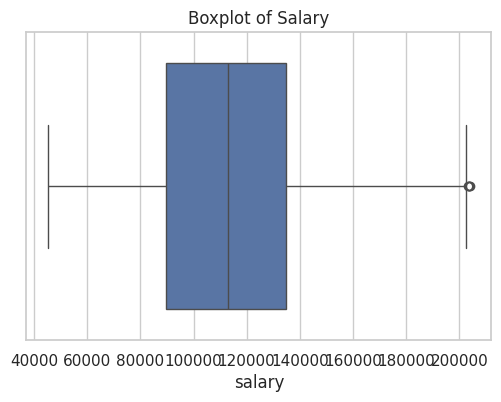

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['salary'])
plt.title("Boxplot of Salary")
plt.show()

In [9]:
df_no_outliers = df[(df['salary'] >= lower) & (df['salary'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (10345, 19)
After removing outliers: (10341, 19)


The IQR method was used to detect outliers in the salary column.
Outliers are values below the lower bound or above the upper bound.
These outliers were removed to reduce the effect of extreme values on the analysis.

In [10]:
features = ['years_experience', 'salary', 'job_openings']
df_norm = df_no_outliers[features].copy()
df_norm.head()

,years_experience,salary,job_openings
0,2,158322,4
1,0,163666,9
2,14,158556,9
3,9,95775,7
4,5,111873,2


In [11]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_minmax = df_norm.copy()
df_minmax[features] = minmax_scaler.fit_transform(df_minmax[features])

df_minmax.head()

,years_experience,salary,job_openings
0,0.142857,0.719252,0.375
1,0.000000,0.753195,1.000
2,1.000000,0.720738,1.000
3,0.642857,0.321977,0.750
4,0.357143,0.424225,0.125


In [12]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
df_zscore = df_norm.copy()
df_zscore[features] = standard_scaler.fit_transform(df_zscore[features])

df_zscore.head()

,years_experience,salary,job_openings
0,-1.146232,1.433113,-0.388895
1,-1.609210,1.603611,1.546408
2,1.631641,1.440579,1.546408
3,0.474194,-0.562424,0.772287
4,-0.451764,-0.048823,-1.163015


Min-Max normalization scales values between 0 and 1.
Z-score normalization standardizes the data so the mean becomes 0 and the standard deviation becomes 1.

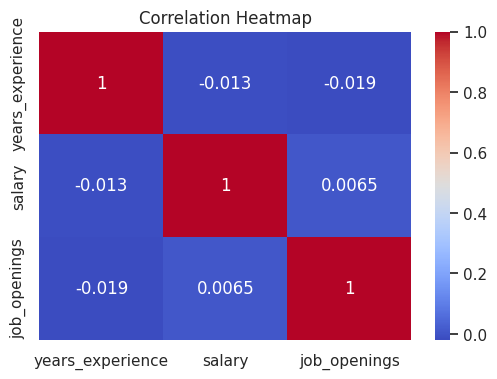

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(df_norm.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that the numerical features have weak correlations. Most correlation values are close to 0, which means there is no strong linear relationship between the features. Therefore, PCA was not applied since it is more effective when strong correlation exists between variables.